# 04 · Statistical Analysis
**Goal:** Validate observed impulse-vs-planned differences with formal statistical tests.

In [1]:
import pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
try:
    import statsmodels.api as sma
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'statsmodels', '-q'])
    import statsmodels.api as sma
df = pd.read_csv('../data/processed/cleaned.csv')
print('Loaded:', df.shape)

Loaded: (13000, 36)


### H1 · Impulse SKUs sell more (Mann-Whitney U)

In [2]:
imp_q = df.loc[df['basket_type']=='Impulse','sold_quantity'].dropna()
pln_q = df.loc[df['basket_type']=='Planned','sold_quantity'].dropna()
print(f'Impulse N={len(imp_q)}, median={imp_q.median()}')
print(f'Planned N={len(pln_q)}, median={pln_q.median()}')
if len(imp_q) > 0 and len(pln_q) > 0:
    stat, p = stats.mannwhitneyu(imp_q, pln_q)
    print(f'U={stat:.0f}  p={p:.4e}  -> {"Significant" if p<0.05 else "Not significant"}')

Impulse N=3744, median=124.0
Planned N=5117, median=120.0
U=9608564  p=8.0387e-01  -> Not significant


### H2 · Offers increase demand (ANOVA)

In [3]:
groups = [g['sold_quantity'].dropna() for _,g in df.groupby('has_offer')]
f_val, p = stats.f_oneway(*groups)
print(f'F={f_val:.2f}  p={p:.4e}  -> {"Offers impact demand" if p<0.05 else "No significant impact"}')
print('\nMean qty by offer status:')
print(df.groupby('has_offer')['sold_quantity'].mean().round(1))

F=0.66  p=4.1496e-01  -> No significant impact

Mean qty by offer status:
has_offer
0    161.5
1    163.4
Name: sold_quantity, dtype: float64


### H3 · Cities differ (Kruskal-Wallis)

In [4]:
cg = [g['impulse_score'].dropna() for _,g in df.groupby('city')]
h, p = stats.kruskal(*cg)
print(f'H={h:.2f}  p={p:.4e}  -> {"Cities differ" if p<0.05 else "No significant difference"}')
print('\nMean impulse score by city:')
print(df.groupby('city')['impulse_score'].mean().sort_values(ascending=False).round(3))

H=9.13  p=4.2553e-01  -> No significant difference

Mean impulse score by city:
city
jaipur       0.463
ahmedabad    0.463
delhi        0.459
chennai      0.457
hyderabad    0.454
kolkata      0.449
lucknow      0.448
bengaluru    0.446
mumbai       0.446
pune         0.442
Name: impulse_score, dtype: float64


### H4 · Small packs cost more per 100g (Welch t-test)

In [5]:
sm_pr = df.loc[df['weight_bucket']=='small','price_per_100g'].dropna()
ot_pr = df.loc[df['weight_bucket']!='small','price_per_100g'].dropna()
t_val, p = stats.ttest_ind(sm_pr, ot_pr, equal_var=False)
print(f'Small packs median price/100g: {sm_pr.median():.2f}')
print(f'Other packs median price/100g: {ot_pr.median():.2f}')
print(f't={t_val:.2f}  p={p:.4e}  -> {"Small packs cost more" if p<0.05 else "Not significant"}')

Small packs median price/100g: 110.44
Other packs median price/100g: 28.84
t=49.40  p=0.0000e+00  -> Small packs cost more


### H5 · Pareto rule

In [6]:
prod_rev = df.groupby('product_id')['revenue_inr'].sum().sort_values(ascending=False)
cum = prod_rev.cumsum() / prod_rev.sum()
idx20 = int(len(cum)*0.2)
print(f'Top 20% of products ({idx20} SKUs) contribute {cum.iloc[idx20]*100:.1f}% of total revenue')

Top 20% of products (2600 SKUs) contribute 60.3% of total revenue


### Correlation Heatmap

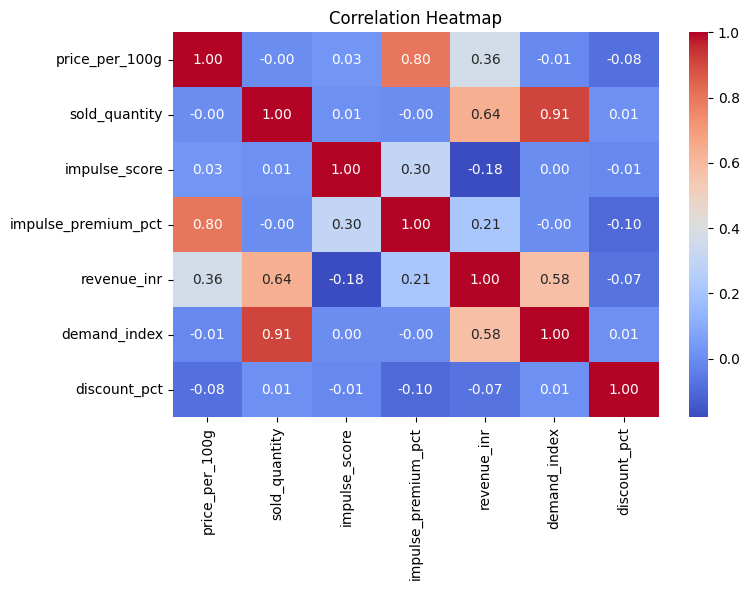

                     price_per_100g  sold_quantity  impulse_score  \
price_per_100g                 1.00          -0.00           0.03   
sold_quantity                 -0.00           1.00           0.01   
impulse_score                  0.03           0.01           1.00   
impulse_premium_pct            0.80          -0.00           0.30   
revenue_inr                    0.36           0.64          -0.18   
demand_index                  -0.01           0.91           0.00   
discount_pct                  -0.08           0.01          -0.01   

                     impulse_premium_pct  revenue_inr  demand_index  \
price_per_100g                      0.80         0.36         -0.01   
sold_quantity                      -0.00         0.64          0.91   
impulse_score                       0.30        -0.18          0.00   
impulse_premium_pct                 1.00         0.21         -0.00   
revenue_inr                         0.21         1.00          0.58   
demand_index         

In [7]:
cols = ['price_per_100g','sold_quantity','impulse_score','impulse_premium_pct','revenue_inr','demand_index','discount_pct']
corr = df[cols].corr().round(2)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=100)
plt.show()
plt.close()
print(corr)

### Linear Regression — what drives quantity sold?

In [8]:
X = df[['has_offer','impulse_score','price_per_100g','discount_pct']].dropna()
y = df.loc[X.index, 'sold_quantity']
X_const = sma.add_constant(X)
model = sma.OLS(y, X_const).fit()
print(model.summary())
print('\nCoefficients (sorted):')
print(model.params[1:].sort_values(ascending=False).round(4))

                            OLS Regression Results                            
Dep. Variable:          sold_quantity   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5832
Date:                Sat, 25 Apr 2026   Prob (F-statistic):              0.675
Time:                        22:20:00   Log-Likelihood:                -81994.
No. Observations:               13000   AIC:                         1.640e+05
Df Residuals:                   12995   BIC:                         1.640e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            159.4530      2.845     56.